# Multi-factor designs — ASCA and linear mixed models

Most metabolomics studies are **not** two-group comparisons. A typical
design might be `treatment × time` with patient IDs (repeated
measures). The two-group `metabol.differential` test is the wrong tool
here.

- **`ov.metabol.asca`** (Smilde 2005) — ANOVA-Simultaneous Component
  Analysis. Decomposes the data into per-factor effect matrices plus
  pairwise interactions, runs PCA on each, and reports
  variance-explained + permutation p-value.
- **`ov.metabol.mixed_model`** — per-feature `statsmodels.MixedLM`
  with a user-defined formula and a random-effect grouping variable
  (e.g. patient ID).

This tutorial uses a **synthetic 2×2 factorial** (treatment × time,
6 patients × 4 cells = 24 samples × 25 features) with:

- Strong treatment effect on features 0–4
- Moderate time effect on features 5–9
- Per-patient random intercept


## 0 — Setup and synthetic factorial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from anndata import AnnData
import omicverse as ov

rng = np.random.default_rng(1)

n_per_cell = 6  # patients
treatments = ['ctrl', 'drug']
times = ['0h', '24h']
n_features = 25

rows, idx = [], []
for t in treatments:
    for tm in times:
        for k in range(n_per_cell):
            rows.append({'treatment': t, 'time': tm, 'patient': f'p{k}'})
            idx.append(f'{t}_{tm}_{k}')
obs = pd.DataFrame(rows, index=idx)
n = len(obs)

X = rng.standard_normal((n, n_features)) * 0.3
tmask = (obs['treatment'] == 'drug').to_numpy()
tm_mask = (obs['time'] == '24h').to_numpy()
X[tmask, 0:5] += 2.0       # treatment effect
X[tm_mask, 5:10] += 1.0    # time effect

# Per-patient random intercept (what MixedLM will estimate)
intercepts = rng.standard_normal(n_per_cell) * 1.0
for i, p in enumerate(obs['patient']):
    X[i, :] += intercepts[int(p[1:])]

var = pd.DataFrame(index=[f'feat{i}' for i in range(n_features)])
adata = AnnData(X=X, obs=obs, var=var)
adata.shape


(24, 25)

## 1 — ASCA

Decompose into `treatment`, `time`, `treatment:time` interaction and
residual. Use 500 permutations for significance testing.


In [2]:
res = ov.metabol.asca(
    adata,
    factors=['treatment', 'time'],
    include_interactions=True,
    n_components=2,
    n_permutations=500,
    seed=0,
)
res.summary()


           effect          ss   df  variance_explained   p_value
0       treatment  115.937051  1.0            0.160197  0.023952
1            time   31.687051  1.0            0.043784  0.365269
2  treatment:time    1.149195  1.0            0.001588  1.000000
3        residual  574.942287  NaN            0.794431       NaN

### Scores plot for the treatment effect

The scores matrix of the `treatment` effect places each sample on a
2-D projection of the factor's subspace. Samples of the same level
should cluster tightly.


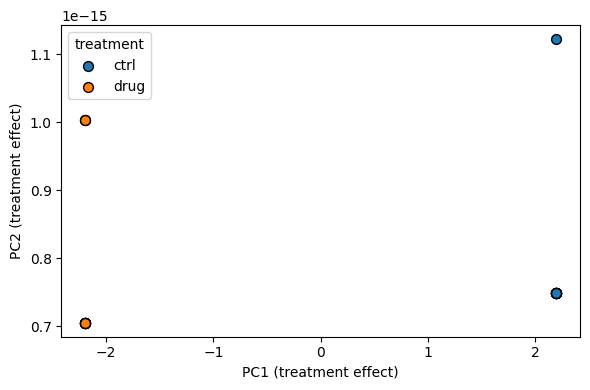

In [3]:
scores = res.scores_frame('treatment')
fig, ax = plt.subplots(figsize=(6, 4))
for lvl, colour in zip(['ctrl', 'drug'], ['C0', 'C3']):
    mask = (adata.obs['treatment'] == lvl).to_numpy()
    ax.scatter(scores.loc[mask, 'PC1'], scores.loc[mask, 'PC2'],
               label=lvl, s=50, edgecolor='k')
ax.set_xlabel('PC1 (treatment effect)')
ax.set_ylabel('PC2 (treatment effect)')
ax.legend(title='treatment')
fig.tight_layout()
plt.show()


### Loadings — which features drive the treatment effect?

In [4]:
load = res.loadings_frame('treatment')
top_treat = load['PC1'].abs().sort_values(ascending=False).head(8)
print('Top treatment-driving features (|PC1 loading|):')
print(top_treat)


Top treatment-driving features (|PC1 loading|):
feat3     0.467249
feat2     0.462797
feat1     0.446272
feat4     0.425777
feat0     0.408436
feat12    0.067782
feat18    0.050729
feat24    0.049333
Name: PC1, dtype: float64


## 2 — Linear mixed model

For a specific per-feature effect size + p-value, fit `MixedLM` with
`treatment + time` as fixed effects and `patient` as the random
intercept. Ask for the `treatment[T.drug]` contrast in short format
to get the same schema as `metabol.differential`.


In [5]:
tbl = ov.metabol.mixed_model(
    adata,
    formula='treatment + time',
    groups='patient',
    term='treatment[T.drug]',
)
tbl.sort_values('pvalue').head(10)


             coef        se       stat        pvalue          padj
feature                                                           
feat3    2.053924  0.103741  19.798582  3.061911e-87  7.654778e-86
feat2    2.034350  0.110201  18.460316  4.308156e-76  5.385195e-75
feat4    1.871621  0.113259  16.525132  2.419114e-61  2.015928e-60
feat0    1.795393  0.108829  16.497441  3.827711e-61  2.392320e-60
feat1    1.961713  0.144438  13.581672  5.143839e-42  2.571919e-41
feat11   0.199102  0.072605   2.742262  6.101756e-03  2.542398e-02
feat12   0.297956  0.128181   2.324500  2.009873e-02  7.178117e-02
feat7    0.213406  0.101708   2.098218  3.588586e-02  1.121433e-01
feat6    0.200778  0.099124   2.025526  4.281340e-02  1.189261e-01
feat18   0.222992  0.121534   1.834820  6.653242e-02  1.663311e-01

The top features should match the planted-signal block (0–4).
FDR correction is applied automatically (`padj` column).


In [6]:
n_sig = (tbl['padj'] < 0.05).sum()
print(f'{n_sig} features with padj < 0.05 for treatment[T.drug]')


6 features with padj < 0.05 for treatment[T.drug]


## 3 — MEBA — time-series Hotelling T²

`mixed_model` gives you per-feature coefficients for the fixed-effect
design. **MEBA** (MetaboAnalyst's time-series module) asks a different
question: *does the entire time-course vector differ between
groups?* — a multivariate test over time points, not separate tests
at each point.

Requires a balanced design: every subject observed at every time
point. We build a fresh synthetic 2 groups × 4 time points × 8
patients so the API is obvious. On features 0–4 the `drug` group
gains over time (group × time interaction); features 5–9 have a
time-only trend with no group difference.


In [7]:
rng = np.random.default_rng(2)
n_subj = 8
n_times = 4
group_ids = ['A']*4 + ['B']*4
rows, idx = [], []
for si, s in enumerate([f'p{i}' for i in range(n_subj)]):
    for t in range(n_times):
        rows.append({'subject': s, 'group': group_ids[si], 'time': f't{t}'})
        idx.append(f'{s}_t{t}')
obs_ts = pd.DataFrame(rows, index=idx)
n = len(obs_ts)
X_ts = rng.standard_normal((n, 15)) * 0.3

# Group × time interaction on features 0..4: drug (B) rises over time
for t in range(n_times):
    tmask = (obs_ts['time'] == f't{t}').to_numpy()
    gmask = (obs_ts['group'] == 'B').to_numpy()
    X_ts[tmask & gmask, 0:5] += t * 2.0

# Time-only main effect on features 5..9 — same pattern in both groups
for t in range(n_times):
    tmask = (obs_ts['time'] == f't{t}').to_numpy()
    X_ts[tmask, 5:10] += t * 1.0

from anndata import AnnData as _AnnData
adata_ts = _AnnData(X=X_ts, obs=obs_ts,
                    var=pd.DataFrame(index=[f'f{i}' for i in range(15)]))

meba_tbl = ov.metabol.meba(adata_ts, group_col='group',
                            time_col='time', subject_col='subject')
meba_tbl.sort_values('pvalue').head(10)


              T2            F  df1  df2    pvalue      padj  n_a  n_b  k
f4   8691.685229  1086.460654    4    3  0.000045  0.000679    4    4  4
f0   3909.991043   488.748880    4    3  0.000150  0.001123    4    4  4
f3   2244.084114   280.510514    4    3  0.000344  0.001458    4    4  4
f1   2066.627498   258.328437    4    3  0.000389  0.001458    4    4  4
f2   1569.142040   196.142755    4    3  0.000586  0.001759    4    4  4
f8    140.185920    17.523240    4    3  0.020276  0.050690    4    4  4
f9     39.705078     4.963135    4    3  0.109544  0.234738    4    4  4
f6     12.705891     1.588236    4    3  0.366748  0.667223    4    4  4
f10    11.440460     1.430058    4    3  0.400334  0.667223    4    4  4
f7      8.689745     1.086218    4    3  0.492666  0.738999    4    4  4

MEBA should rank the group×time features (0–4) above the
time-only block (5–9) because the *shape* of the trajectory differs
only for the former.


In [8]:
assert meba_tbl.iloc[:5]['F'].mean() > meba_tbl.iloc[5:10]['F'].mean(), \
       'unexpected — planted signal not recovered'
print(f"Mean F on interaction block (f0..f4) : {meba_tbl.iloc[:5]['F'].mean():.1f}")
print(f"Mean F on time-only block   (f5..f9) : {meba_tbl.iloc[5:10]['F'].mean():.1f}")
print(f"{(meba_tbl['padj'] < 0.05).sum()} features significant at padj < 0.05")


Mean F on interaction block (f0..f4) : 462.0
Mean F on time-only block   (f5..f9) : 5.2
5 features significant at padj < 0.05


## Takeaways

- `asca` — global structure; answers *which factor explains overall
  variance?*
- `mixed_model` — per-feature effect size + p; answers *which
  metabolites change with treatment while respecting patient
  identity?*

Use them together: ASCA to choose which factor is worth testing,
MixedLM to get publication-ready per-feature statistics.
